# Downloading and managing data

In this tutorial you are going to learn how to:

<div class="alert alert-block alert-warning">
    
**[Writing a NOMAD query](#Writing-a-NOMAD-query)**

**[Querying the NOMAD API](#Querying-the-NOMAD-API)**

**[Analyzing the data](#Analyzing-the-data)**

**[Automatic processing](#Automatic-processing)**
   
</div>

Let's get started!

In [1]:
query = {
    "results.material.structural_type:any": [
      "bulk"
    ],
    "results.method.method_name:any": [
      "DFT"
    ],
    "datasets.dataset_name:any": [
      "Hybrid organic inorganic perovskite"
    ],
    "results.properties.available_properties:all": [
      "dos_electronic"
    ],
    "results.material.elements:all": [
      "O"
    ]
  }

## Using an API to download data

In [2]:
from madas.apis import NOMAD_API as API

In [3]:
api = API()

In [4]:
materials = api.get_calculations_by_search(query, max_entries=1)

Found 10 entries
Possibly not all entries discovered due to max_entries limit
Finished download.


In [5]:
example_material = materials[0]
print(example_material)

Material(mid = 02BiKdaavjJP86a6Bnc75l23qSK6, formula = Br3H4PbNO, data = {'archive'}, properties = set())


In [6]:
from madas.plotting import plot_material

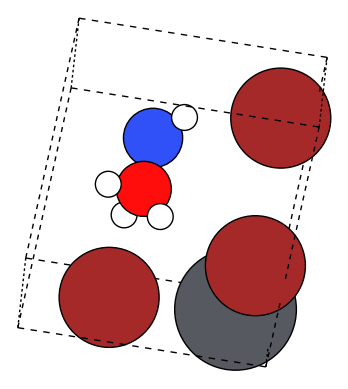

In [7]:
plot_material(example_material,
              repeat=[1,1,1], 
              show_unit_cell=2)

In [9]:
print(type(example_material.atoms))

<class 'ase.atoms.Atoms'>


In [8]:
print(example_material.data.keys())

dict_keys(['archive'])


In [12]:
print(example_material.data['archive'].keys())

dict_keys(['processing_logs', 'run', 'workflow', 'metadata', 'results', 'm_ref_archives'])


In [10]:
print(example_material.properties)

{}


We can also find the reduced formula in the NOMAD archive. This information can be extracted from the `Material` object:

In [23]:
example_material.get_data_by_path('archive/run/0/system/0/chemical_composition_reduced')

'Br3H4PbNO'

You can use a different path to extract any information from the `data` of a `Material`. Similarly, for properties, `Material.get_property_by_path()` can be used.

## Storing `Material`s in a `MaterialsDatabase`

In [24]:
from madas import MaterialsDatabase

In [25]:
db = MaterialsDatabase(filename='hybrid_organic_inorganic_perovskites.db')

In [26]:
len(db)

400

In [27]:
db.fill_database(query)

2026-04-02 18:38:27,953 - hybrid_organic_inorganic_perovskites_log - INFO - Query has already been performed.


In [28]:
len(db)

400

In [29]:
db.log_file_path

'/home/martin/dev/MADAS/madas-docs/tutorials/data/.hybrid_organic_inorganic_perovskites_logs/hybrid_organic_inorganic_perovskites_errors.log'

In [30]:
with open(db.log_file_path, 'r') as f_:
    logfile=f_.readlines()

In [22]:
print(''.join(logfile[-5:]))

2026-04-01 18:03:49,944 - hybrid_organic_inorganic_perovskites_api - INFO - Wrote material with id 2KqdTmVdf4LMALP9skF5qy3Bk-Z3.
2026-04-01 18:03:49,947 - hybrid_organic_inorganic_perovskites_api - INFO - Wrote material with id l59LRbRJg2VmwEsdTZHBZGaRJstZ.
2026-04-01 18:03:49,958 - hybrid_organic_inorganic_perovskites_api - INFO - Wrote material with id m5ik-USpD2-bzxHkT1rInpyRZH4r.
2026-04-01 18:03:49,964 - hybrid_organic_inorganic_perovskites_api - INFO - Wrote material with id WSAauUiR_E1LeYfm819G3O7ui8Sj.
2026-04-01 18:03:49,971 - hybrid_organic_inorganic_perovskites_api - INFO - Wrote material with id FhrE1dmvf6VcZyoViiIOteaMKc8n.



Benefits of a logfile: 
- track provenance
- auto timing

In [55]:
db[0]

Material(mid = r0nrMz72q7RGOSq9TzFu8ydzOiS7, data = {'archive'}, properties = set())

In [31]:
db['r0nrMz72q7RGOSq9TzFu8ydzOiS7']

Material(mid = r0nrMz72q7RGOSq9TzFu8ydzOiS7, formula = Cl3H4SnNO, data = {'dos_energies', 'dos_values', 'archive'}, properties = set())

In [32]:
from madas.utils import tqdm

In [33]:
volumes = []
for entry in tqdm(db):
    volumes.append(entry.atoms.get_volume())

  0%|          | 0/400 [00:00<?, ?it/s]

In [34]:
import matplotlib.pyplot as plt

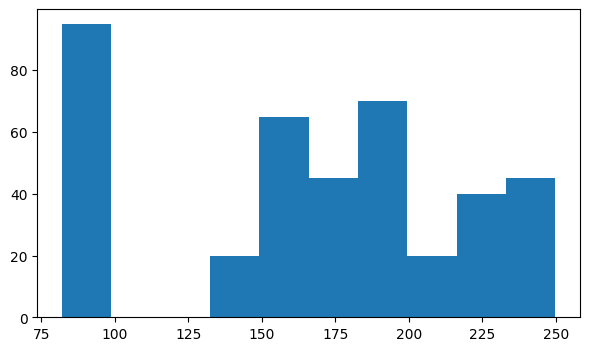

In [35]:
plt.figure(figsize=(7,4))
plt.hist(volumes)
plt.show()

## Derive properties in your database

In [36]:
from madas.utils import print_key_paths, resolve_nested_dict

In [37]:
print_key_paths('band_gap', example_material.data)

/archive/run/0/calculation/0/dos_electronic/0/band_gap
/archive/run/0/calculation/0/band_structure_electronic/0/band_gap
/archive/results/properties/electronic/band_structure_electronic/band_gap
/archive/results/properties/electronic/dos_electronic/band_gap


In [38]:
resolve_nested_dict(example_material.data, 'archive/results/properties/electronic/dos_electronic/band_gap')

[{'index': 0,
  'energy_highest_occupied': 3.822793448724e-20,
  'energy_lowest_unoccupied': 3.822793448724e-20}]

In [39]:
from scipy.constants import electron_volt

In [40]:
gap_data = resolve_nested_dict(example_material.data, 'archive/results/properties/electronic/dos_electronic/band_gap')[0]

In [41]:
gap = (gap_data['energy_lowest_unoccupied'] - gap_data['energy_highest_occupied']) / electron_volt

In [42]:
gap

0.0

In [43]:
from madas import Material

In [44]:
def get_gap(material: Material) -> float:
    gap_data = resolve_nested_dict(material.data, 'archive/results/properties/electronic/dos_electronic/band_gap')[0]
    gap = (gap_data['energy_lowest_unoccupied'] - gap_data['energy_highest_occupied']) / electron_volt
    return gap

In [45]:
band_gaps = []
for entry in tqdm(db):
    band_gaps.append(get_gap(entry))

  0%|          | 0/400 [00:00<?, ?it/s]

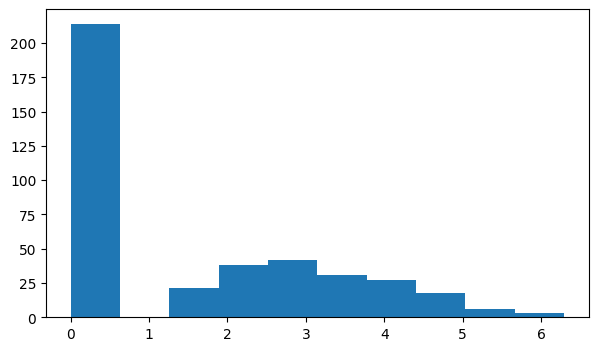

In [46]:
plt.figure(figsize=(7,4))
plt.hist(band_gaps)
plt.show()

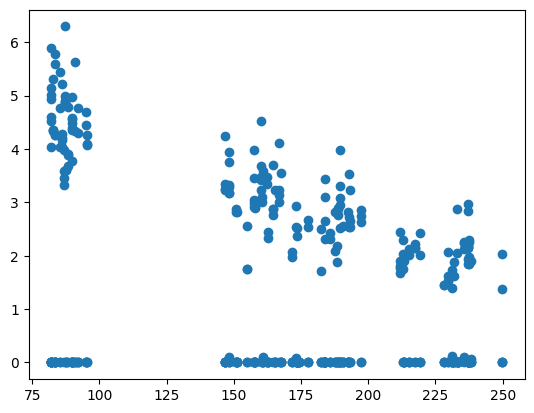

In [47]:
plt.scatter(volumes, band_gaps)

In [48]:
mids, properties_dicts = [], []
for entry in tqdm(db):
    mids.append(entry.mid)
    properties_dicts.append({'band_gap':get_gap(entry), 'volume':entry.atoms.get_volume()})

  0%|          | 0/400 [00:00<?, ?it/s]

In [49]:
db.update_entries(mids, properties_dicts)

In [50]:
db[0]

Material(mid = E3M04tTIcjIHGPkHM6be5dfaX6sF, formula = F3H4GeNO, data = {'dos_energies', 'dos_values', 'archive'}, properties = {'band_gap', 'volume'})

## Retrieving properties

In [51]:
band_gaps = db.get_properties('band_gap')

  0%|          | 0/400 [00:00<?, ?it/s]

In [55]:
df = db.get_property_dataframe(['volume', 'band_gap'])

In [53]:
dataframe = db.get_property_dataframe(['volume', 'band_gap', 'archive/results/material/symmetry/space_group_number'])

In [54]:
dataframe.describe()

,volume,band_gap,archive/results/material/symmetry/space_group_number
count,400.000000,400.000000,400.0
mean,166.781115,1.475016,1.0
std,51.909401,1.747633,0.0
min,82.050231,0.000000,1.0
25%,146.843302,0.000000,1.0
50%,173.365157,0.000000,1.0
75%,212.009954,2.880850,1.0
max,249.762117,6.293500,1.0
